In [1]:
try: # install all dependencies in colab 
    import google.colab
    !sudo apt-get update -y
    !sudo apt-get install -y libnvidia-gl-555 vulkan-tools glslang-tools vulkan-validationlayers-dev
    !pip install pyav==13.1.0
    !pip install git+https://github.com/rdv/rdv.git
except:
    print("Executing locally")

Executing locally


In [2]:
import os
# os.environ['RDV_DEBUG'] = 'True'  ## uncomment to enable debug logging from vulkan
import rdv
import torch

In [3]:
# Generate positions and colors for the "gaussians"
positions = rdv.vec3.randd(100000, device=rdv.device())
colors = torch.rand_like(positions)
# copy tensors to vulkan visible memory now...
positions = rdv.tensor_copy(positions)
colors = rdv.tensor_copy(colors)

In [4]:
# Create the gaussian 3D field
gs_map = rdv.GS3D(positions, colors, radius=0.025)
gs_map.build_ads() # IMPORTANT: build the acceleration data structure before rendering

In [5]:
# Create camera poses (1 position,target,up)
camera_poses = rdv.tensor_copy( torch.tensor([-3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], dtype=torch.float32).reshape(1, 9) )
# Create sensor for 1 camera and 1024x1024 resolution, with samples at each exact pose and center of the pixel
sensor = rdv.Sensor(1, 1024, 1024, samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.CENTER, rdv.SampleLocation.CENTER), probes_map=rdv.CameraProbes(
    camera_poses=camera_poses
))
# create a capturer of a view of the gs_map
capture_image = sensor.view(gs_map, samples = 1)


In [8]:
# capture the field and get the first image
import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"Rendered in {time.perf_counter() - t} seconds")

Rendered in 0.003168448805809021 seconds


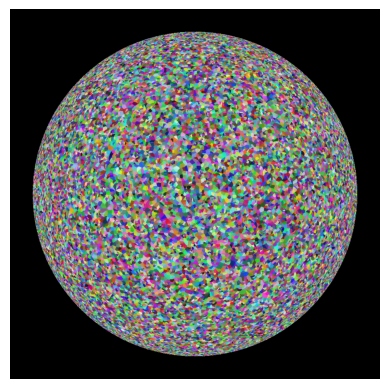

In [9]:
# view the image with matplotlib
import matplotlib.pyplot as plt
plt.imshow(image.cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.show()